In [1]:
import run

In [2]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"

In [3]:
from src import data_broker
from src import calendar_iterator
from src import strategy_selector_1
from src import filter_optimizer_1
from src import performance_evaluator_1,performance_evaluator

In [4]:
# params
initial_capital= 100000.0
transaction_cost_pct=.001
forward_month=6
allocation_type='equal'

In [5]:
# 1. Set up all components
tickers=["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL"]
broker = data_broker.DataBroker(tickers=tickers, start_date="2022-01-01", end_date="2026-06-01")
universe_data = broker.fetch_universe_data()
is_data,oos_data=broker.split_train_test(universe_data,forward_month)

[*********************100%***********************]  5 of 5 completed


In [6]:
calendar = calendar_iterator.CalendarIterator(is_data, interval="ME")
rebalance_dates = calendar.generate_rebalance_dates()
portfolio_filter = filter_optimizer_1.VolumeWeightFilter(top_percent=0.40, min_dollar_volume=10_000_000, allocation_type=allocation_type)

In [7]:
strateties={
    'raw_mom':strategy_selector_1.MomentumStrategy(lookback_days=252),
    'adj_mom':strategy_selector_1.RiskAdjustedMomentum(lookback_days=252),
    'info':strategy_selector_1.InformationDiscreteMomentum(lookback_days=252),
    # 'info_std2':strategy_selector_1.InformationDiscreteWithExhaustion(lookback_days=252, z_threshold=2),
    # 'info_std3':strategy_selector_1.InformationDiscreteWithExhaustion(lookback_days=252, z_threshold=3),
}


In [8]:
evaluators,nav_dfs,reports={},{},{}

for strategy_key in strateties:
    strategy=strateties[strategy_key]
    evaluator= run.run(universe_data,rebalance_dates, calendar,strategy,portfolio_filter)
    df_nav,report=run.get_df_nav(evaluator)

    evaluators[strategy_key]=strategy
    nav_dfs[strategy_key]=df_nav
    reports[strategy_key]=report

In [9]:
nav_dfs.keys()

dict_keys(['raw_mom', 'adj_mom', 'info'])

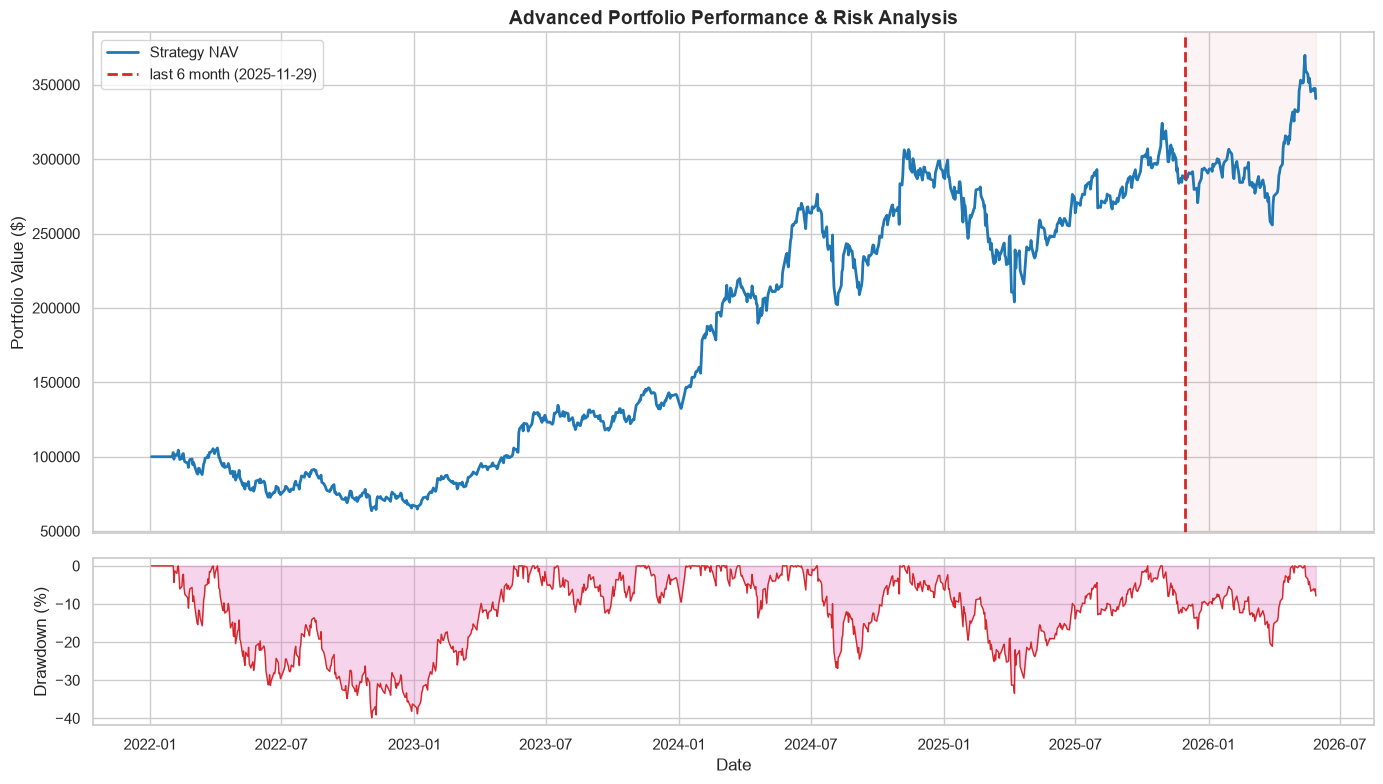

In [10]:
df_nav=nav_dfs['info']
run.plot_nav_charts(df_nav)

In [15]:
#import matplotlib.pyplot as plt
# plt.figure(figsize=(14, 6))
# for key in nav_dfs:
#     df_nav=nav_dfs[key]
#     plt.plot(df_nav, label=key) #, )color='gray', alpha=0.7)

# plt.title('Alpha Comparison: Checking the Impact of Volume Exhaustion')
# plt.ylabel('Portfolio Value ($)')
# plt.legend()
# plt.show()

In [11]:
# Initialize the Plotly figure
fig = go.Figure()

for key, df_nav in nav_dfs.items():
    # Detect if the value is a DataFrame (take first column) or a Series
    y_values = df_nav.iloc[:, 0] if isinstance(df_nav, pd.DataFrame) else df_nav
    
    fig.add_trace(go.Scatter(
        x=df_nav.index,
        y=y_values,
        mode='lines',
        name=key
    ))

# Update layout to match your titles and dimensions
fig.update_layout(
    title='Alpha Comparison: Checking the Impact of Volume Exhaustion',
    xaxis_title='Index / Date',
    yaxis_title='Portfolio Value ($)',
    width=1200,   # Adjust width to match your screen preferences (corresponds to 14)
    height=550,   # Adjust height (corresponds to 6)
    template='plotly_white', # Clean background style
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

# Display the interactive chart
fig.show()

In [12]:
df_navs= pd.concat(nav_dfs,axis=1)
df_navs.columns=nav_dfs.keys()

df_returns=df_navs.pct_change().dropna()
df_metrics=run.compute_performance_metrics(df_navs)

df_navs.tail()

,raw_mom,adj_mom,info
date,,,
2026-05-22,397137.658747,357773.499300,345204.558608
2026-05-26,399741.099379,360091.747726,347467.551187
2026-05-27,397614.924657,358868.646475,345619.413166
2026-05-28,399817.197812,364673.979966,347533.698340
2026-05-29,391890.524467,367611.018737,340643.584263


In [13]:
# Generate the summary statistics
df_stats = df_returns.describe().transpose()

# Create the scatter plot using the index as the 'text' argument
fig = px.scatter(
    df_stats, 
    x='std', 
    y='mean', 
    text=df_stats.index,  # This puts the labels on the chart
    title='Strategy Risk vs. Return (Mean vs. Std Dev)'
)

# Tweak label positioning so they don't sit directly on top of the dots
fig.update_traces(textposition='top center')
fig.show()

In [24]:
# approximate sharpe ratio
(df_stats['mean']/df_stats['std']).sort_values(ascending=False)

raw_mom    0.064615
adj_mom    0.062600
info       0.059516
dtype: float64

# bench mark

In [14]:
broker = data_broker.DataBroker(tickers=["SPY","QQQ"], start_date="2022-01-01", end_date="2026-06-01")
benchmark_data = broker.fetch_universe_data()['price']

[*********************100%***********************]  2 of 2 completed


In [15]:
df_metrics_benchmark=run.compute_performance_metrics(benchmark_data)

In [16]:
df_metrics.sort_values('Sharpe Ratio', ascending=False)

,CAGR (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio
raw_mom,36.544362,0.919911,1.370818,-39.839392,0.917292
adj_mom,34.567221,0.886613,1.331626,-39.839392,0.867664
info,32.249291,0.837928,1.264377,-39.839392,0.809483


In [17]:
df_metrics_benchmark

,CAGR (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Calmar Ratio
QQQ,15.587258,0.571465,0.815108,-34.827987,0.44755
SPY,12.539214,0.536093,0.741278,-24.496373,0.51188


In [ ]:
# 所以我们